In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from word2number import w2n
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv('hiring.csv')
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [ ]:
df.fillna({
    'experience': 'zero',
    'test_score(out of 10)': df['test_score(out of 10)'].median()
}, inplace=True)
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,zero,8.0,9,50000
1,zero,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,8.0,7,72000
7,eleven,7.0,8,80000


In [ ]:
df['experience'] = df.experience.apply(lambda x: w2n.word_to_num(x))

In [ ]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


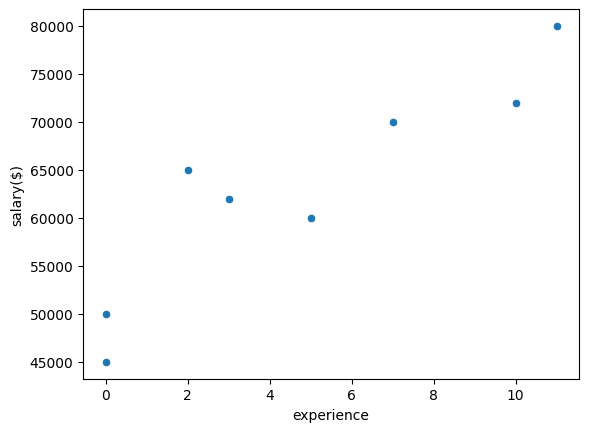

In [ ]:
sns.scatterplot(data=df, x='experience', y='salary($)')
plt.show()

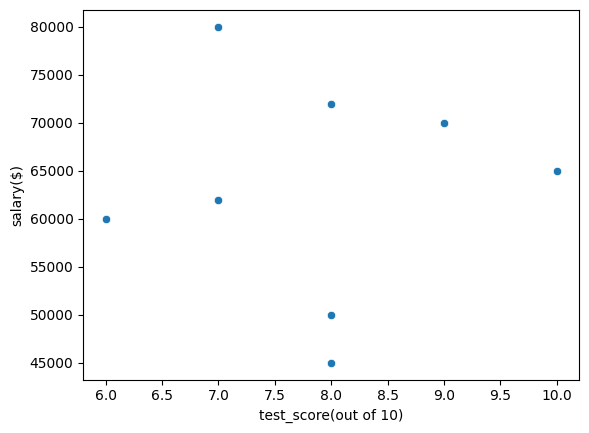

In [ ]:
sns.scatterplot(data=df, x='test_score(out of 10)', y='salary($)')
plt.show()

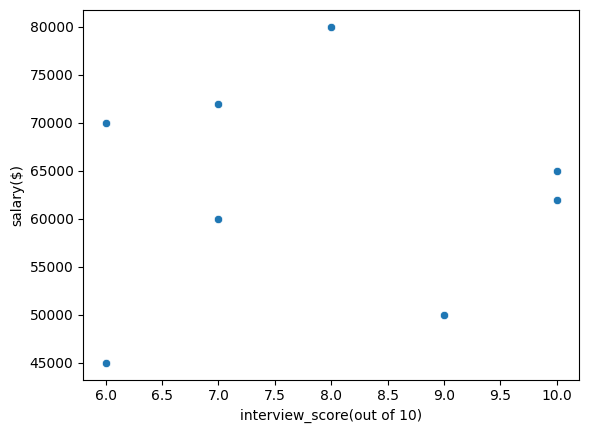

In [ ]:
sns.scatterplot(data=df, x='interview_score(out of 10)', y='salary($)')
plt.show()

In [ ]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


In [ ]:
X = df[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']]
X

,experience,test_score(out of 10),interview_score(out of 10)
0,0,8.0,9
1,0,8.0,6
2,5,6.0,7
3,2,10.0,10
4,7,9.0,6
5,3,7.0,10
6,10,8.0,7
7,11,7.0,8


In [ ]:
Y = df['salary($)']
Y

,salary($)
0,50000
1,45000
2,60000
3,65000
4,70000
5,62000
6,72000
7,80000


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
X_train

,experience,test_score(out of 10),interview_score(out of 10)
0,0,8.0,9
7,11,7.0,8
2,5,6.0,7
4,7,9.0,6
3,2,10.0,10
6,10,8.0,7


In [ ]:
X_test

,experience,test_score(out of 10),interview_score(out of 10)
1,0,8.0,6
5,3,7.0,10


In [ ]:
model = LinearRegression().fit(X_train, Y_train)

In [ ]:
Y_test

,salary($)
1,45000
5,62000


In [ ]:
model.predict(X_test)

array([47422.9425232 , 60018.43595614])

In [ ]:
model.score(X_test, Y_test)

0.9321989859471912